In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import zipfile

# 1. הגדרת נתיבים (מותאם למחברת בתוך תיקיית notebooks)
BASE_DIR = Path(os.getcwd()).parent
ZIP_PATH = BASE_DIR / "data" / "raw" / "rais_anonymized.zip"
DATA_DIR = BASE_DIR / "data" / "processed_parquet"
DATA_DIR.mkdir(parents=True, exist_ok=True)

# 2. חילוץ שאלוני ה-STAI וה-PANAS ישירות מקובץ ה-ZIP
print("מחלץ שאלונים מקובץ ה-ZIP...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    with z.open('rais_anonymized/scored_surveys/stai.csv') as f:
        stai = pd.read_csv(f)
    with z.open('rais_anonymized/scored_surveys/panas.csv') as f:
        panas = pd.read_csv(f)

# שמירה לפורמט Parquet לעבודה מהירה בהמשך
stai.to_parquet(DATA_DIR / "stai.parquet")
panas.to_parquet(DATA_DIR / "panas.parquet")

# 3. נרמול תאריכים
stai['date'] = pd.to_datetime(stai['submitdate'], errors='coerce').dt.normalize()
panas['date'] = pd.to_datetime(panas['submitdate'], errors='coerce').dt.normalize()

# 4. יצירת מילון המזהים (new_id) מתוך השאלונים עצמם
# שולפים את כל המזהים הארוכים (הייחודיים) מתוך שני השאלונים
unique_long_ids = pd.concat([stai['user_id'], panas['user_id']]).dropna().unique()

id_mapping = pd.DataFrame({
    'id': unique_long_ids,
    'new_id': range(1, len(unique_long_ids) + 1)
})

# 5. טיפול בטבלאות כדי ליצור את stai_clean ו-panas_clean
stai_clean = stai.rename(columns={'user_id': 'id'})
stai_clean = pd.merge(stai_clean, id_mapping, on='id', how='inner')

panas_clean = panas.rename(columns={'user_id': 'id'})
panas_clean = pd.merge(panas_clean, id_mapping, on='id', how='inner')

print(f"✅ השאלונים נטענו בהצלחה! סה\"כ משתתפים שונים במחקר: {len(id_mapping)}")

מחלץ שאלונים מקובץ ה-ZIP...
✅ השאלונים נטענו בהצלחה! סה"כ משתתפים שונים במחקר: 53


In [3]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. מציאת ה-Baseline (היום הראשון) מתוך השאלונים בלבד!
# ---------------------------------------------------------
all_dates = pd.concat([
    stai_clean[['new_id', 'date']], 
    panas_clean[['new_id', 'date']]
])
baseline_dates = all_dates.groupby('new_id')['date'].min().reset_index(name='first_study_day')

# ---------------------------------------------------------
# 2. יצירת טבלת אגרגציה שבועית (Weekly Aggregation)
# ---------------------------------------------------------
stai_with_baseline = pd.merge(stai_clean, baseline_dates, on='new_id', how='left')
panas_with_baseline = pd.merge(panas_clean, baseline_dates, on='new_id', how='left')

stai_with_baseline['study_week'] = ((stai_with_baseline['date'] - stai_with_baseline['first_study_day']).dt.days // 7) + 1
panas_with_baseline['study_week'] = ((panas_with_baseline['date'] - panas_with_baseline['first_study_day']).dt.days // 7) + 1

weekly_stai = stai_with_baseline.groupby(['new_id', 'study_week'])['stai_stress'].mean().reset_index()
weekly_panas = panas_with_baseline.groupby(['new_id', 'study_week'])[['positive_affect_score', 'negative_affect_score']].mean().reset_index()

weekly_surveys_merged = pd.merge(weekly_stai, weekly_panas, on=['new_id', 'study_week'], how='outer')
weekly_surveys_merged = pd.merge(weekly_surveys_merged, baseline_dates, on='new_id', how='left')

weekly_surveys_df = pd.merge(weekly_surveys_merged, id_mapping, on='new_id', how='left')
ordered_columns = ['id', 'new_id', 'study_week', 'stai_stress', 'positive_affect_score', 'negative_affect_score']
weekly_surveys_df = weekly_surveys_df[ordered_columns].sort_values(by=['new_id', 'study_week']).reset_index(drop=True)

# ---------------------------------------------------------
# 3. דו"ח סטטיסטי קליני (EDA)
# ---------------------------------------------------------
print("==================================================")
print("     דו\"ח סטטיסטי קליני: נתונים גולמיים (EDA)")
print("==================================================\n")

print("--- 1. נתונים כלליים: שאלונים זמינים ---")
total_users = len(id_mapping)
stai_count = len(stai_clean)
panas_count = len(panas_clean)

print(f"סך הכל נבדקים שונים עם שאלונים: {total_users}")
print(f"סך הכל שאלוני STAI שמולאו: {stai_count}")
print(f"סך הכל שאלוני PANAS שמולאו: {panas_count}")
print(f"ממוצע שאלוני STAI לנבדק: {stai_count / total_users:.2f}")
print(f"ממוצע שאלוני PANAS לנבדק: {panas_count / total_users:.2f}\n")

print("--- 2. ניתוח רציפות ומרווחים (Gaps Analysis) ---")
combined_surveys_df = pd.concat([
    stai_clean[['new_id', 'date']].assign(type='STAI'),
    panas_clean[['new_id', 'date']].assign(type='PANAS')
]).sort_values(by=['new_id', 'date'])

combined_surveys_df['days_since_last'] = combined_surveys_df.groupby('new_id')['date'].diff().dt.days
survey_gaps_df = combined_surveys_df[combined_surveys_df['days_since_last'] > 10]
users_with_gaps_count = survey_gaps_df['new_id'].nunique()

print(f"מספר הפעמים הכולל שנרשם פער של יותר מ-10 ימים: {len(survey_gaps_df)}")
print(f"מספר הנבדקים שחוו פער כזה: {users_with_gaps_count} מתוך {total_users}")
if not survey_gaps_df.empty:
    print(f"המרווח הגדול ביותר ללא מענה נרשם על: {combined_surveys_df['days_since_last'].max():.0f} ימים.\n")

print("--- 3. ניתוח רגשות קיצוניים (PANAS ו-STAI) ---")
panas_threshold = 35
stai_threshold = 50

extreme_panas_df = panas_clean[panas_clean['negative_affect_score'] >= panas_threshold]
extreme_stai_df = stai_clean[stai_clean['stai_stress'] >= stai_threshold]

print(f"[PANAS] סה\"כ דיווחים על רגש שלילי גבוה ({panas_threshold}+): {len(extreme_panas_df)}")
if len(extreme_panas_df) > 0:
    print(f"        דווח על ידי {extreme_panas_df['new_id'].nunique()} נבדקים שונים.")

print(f"[STAI] סה\"כ דיווחים על חרדה ולחץ קיצוני ({stai_threshold}+): {len(extreme_stai_df)}")
if len(extreme_stai_df) > 0:
    print(f"        דווח על ידי {extreme_stai_df['new_id'].nunique()} נבדקים שונים.\n")

print("--- 4. שורות זמינות לחישוב Delta ---")
past_weeks_df = weekly_surveys_df.copy()
past_weeks_df['match_week'] = past_weeks_df['study_week'] + 1
past_weeks_df = past_weeks_df.rename(columns={'stai_stress': 'prev_stai_stress'})

weekly_pairs_df = pd.merge(
    weekly_surveys_df,
    past_weeks_df[['new_id', 'match_week', 'prev_stai_stress']],
    left_on=['new_id', 'study_week'],
    right_on=['new_id', 'match_week'],
    how='inner'
)
print(f"סה\"כ תצפיות רציפות (שבוע מול שבוע קודם) שזמינות לאימון: {len(weekly_pairs_df)}")

     דו"ח סטטיסטי קליני: נתונים גולמיים (EDA)

--- 1. נתונים כלליים: שאלונים זמינים ---
סך הכל נבדקים שונים עם שאלונים: 53
סך הכל שאלוני STAI שמולאו: 279
סך הכל שאלוני PANAS שמולאו: 268
ממוצע שאלוני STAI לנבדק: 5.26
ממוצע שאלוני PANAS לנבדק: 5.06

--- 2. ניתוח רציפות ומרווחים (Gaps Analysis) ---
מספר הפעמים הכולל שנרשם פער של יותר מ-10 ימים: 69
מספר הנבדקים שחוו פער כזה: 39 מתוך 53
המרווח הגדול ביותר ללא מענה נרשם על: 111 ימים.

--- 3. ניתוח רגשות קיצוניים (PANAS ו-STAI) ---
[PANAS] סה"כ דיווחים על רגש שלילי גבוה (35+): 18
        דווח על ידי 11 נבדקים שונים.
[STAI] סה"כ דיווחים על חרדה ולחץ קיצוני (50+): 124
        דווח על ידי 37 נבדקים שונים.

--- 4. שורות זמינות לחישוב Delta ---
סה"כ תצפיות רציפות (שבוע מול שבוע קודם) שזמינות לאימון: 145


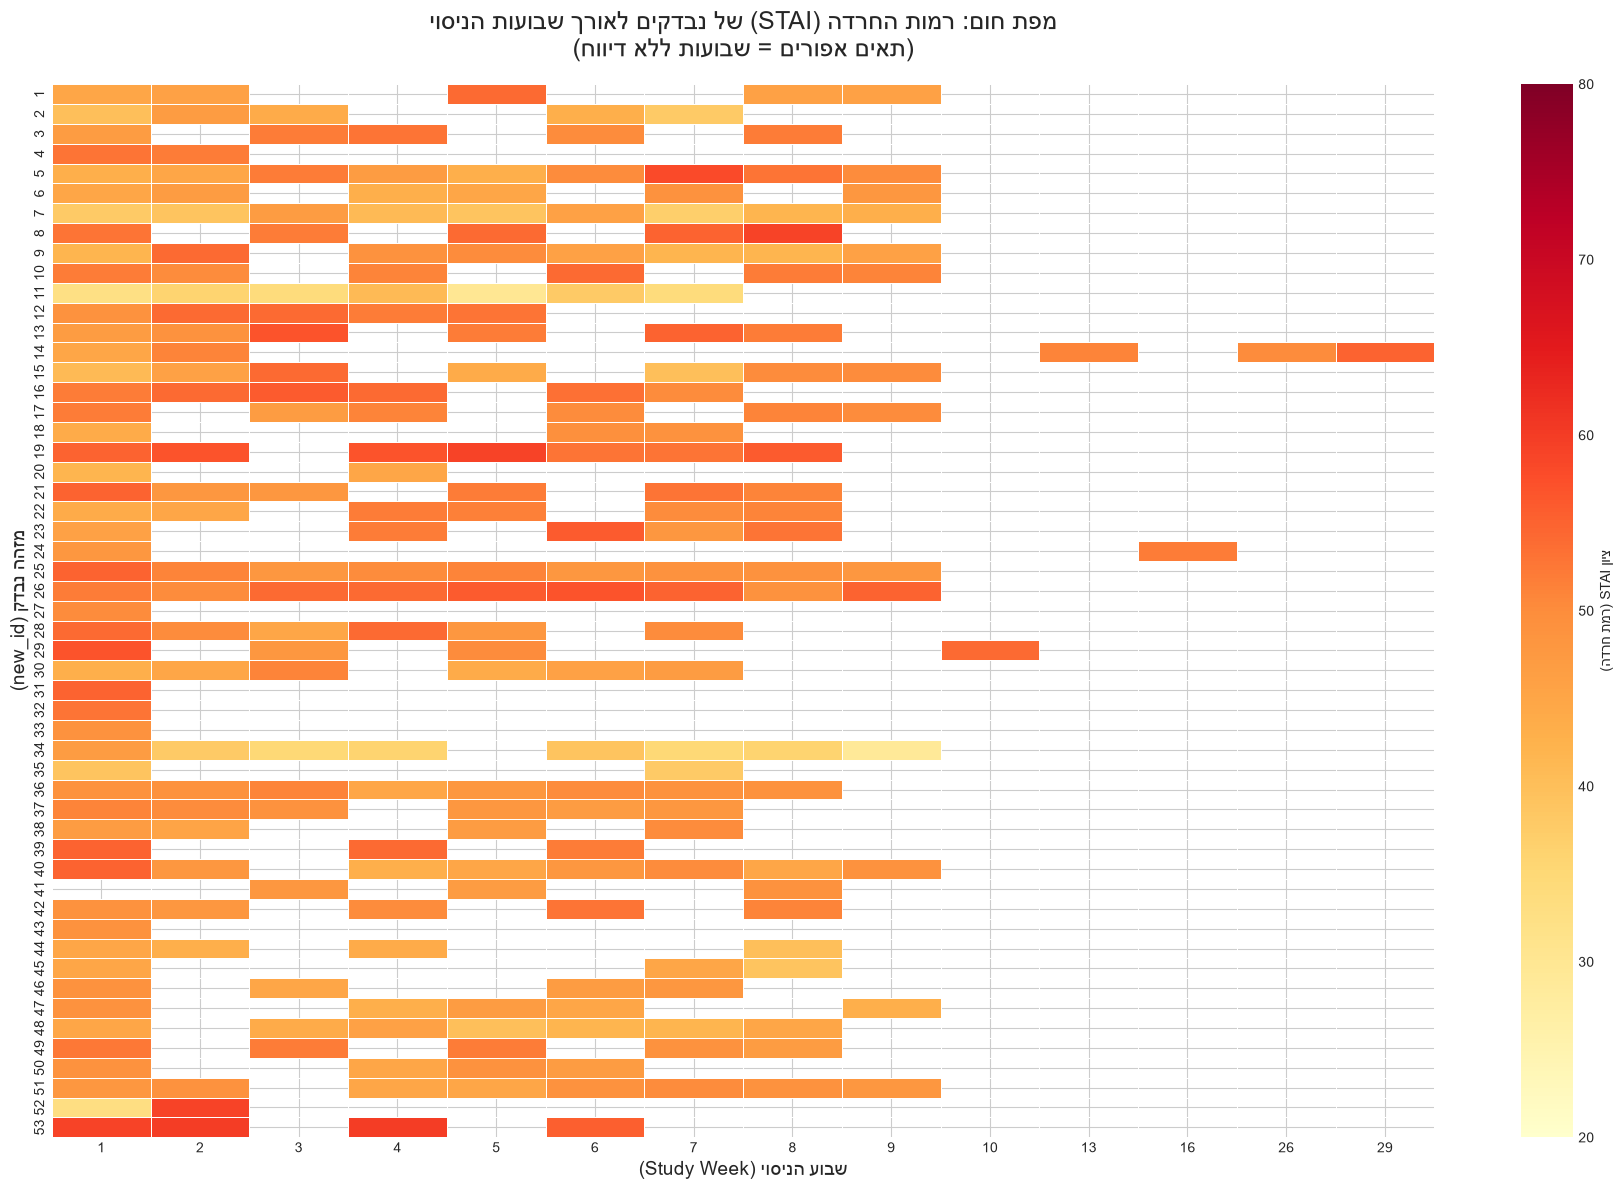

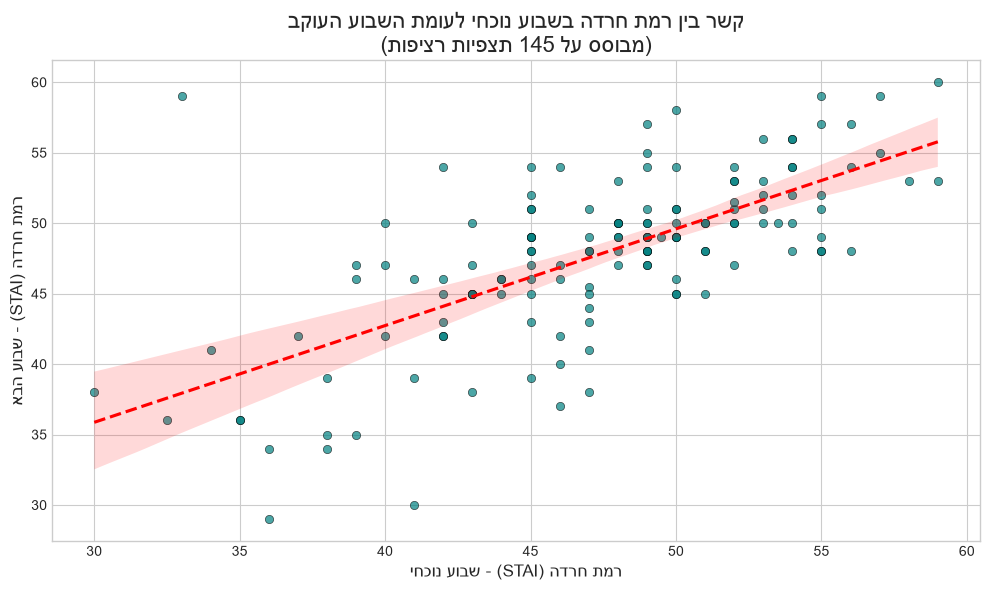

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# עיצוב כללי לגרפים
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# =========================================================
# 1. מפת חום: מעקב רמות חרדה (STAI) ורציפות לאורך שבועות הניסוי
# =========================================================
# ניצור טבלת ציר (Pivot) - שורות: נבדקים, עמודות: שבועות, ערכים: ציון חרדה
pivot_stai = weekly_surveys_df.pivot(index='new_id', columns='study_week', values='stai_stress')

plt.figure(figsize=(18, 12))
# נשתמש במפת צבעים (YlOrRd) - צהוב לחרדה נמוכה, אדום לחרדה גבוהה
# נגדיר שערכים חסרים (NaN) יופיעו בצבע אפור בהיר
sns.heatmap(pivot_stai, cmap="YlOrRd", linewidths=.5, linecolor='white', 
            cbar_kws={'label': 'ציון STAI (רמת חרדה)'}, 
            facecolor='lightgrey', # צבע הרקע לתאים ריקים (חורים בנתונים)
            vmin=20, vmax=80)      # טווח הגיוני לשאלון STAI

plt.title("מפת חום: רמות החרדה (STAI) של נבדקים לאורך שבועות הניסוי\n(תאים אפורים = שבועות ללא דיווח)", fontsize=18, pad=20)
plt.xlabel("שבוע הניסוי (Study Week)", fontsize=14)
plt.ylabel("מזהה נבדק (new_id)", fontsize=14)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================================================
# 2. ניתוח רציפות (Delta) - השוואת חרדה בין שבועות עוקבים
# =========================================================
# שימוש בטבלת הזוגות שנעמה כבר הכינה (weekly_pairs_df)
if not weekly_pairs_df.empty:
    plt.figure(figsize=(10, 6))
    
    # גרף פיזור המראה את החרדה בשבוע הנוכחי מול השבוע הבא
    sns.scatterplot(data=weekly_pairs_df, x='prev_stai_stress', y='stai_stress', 
                    alpha=0.7, color='teal', edgecolor='black')
    
    # הוספת קו מגמה (רגרסיה ליניארית)
    sns.regplot(data=weekly_pairs_df, x='prev_stai_stress', y='stai_stress', 
                scatter=False, color='red', line_kws={'linestyle':'--'})
    
    plt.title(f"קשר בין רמת חרדה בשבוע נוכחי לעומת השבוע העוקב\n(מבוסס על {len(weekly_pairs_df)} תצפיות רציפות)", fontsize=16)
    plt.xlabel("רמת חרדה (STAI) - שבוע נוכחי", fontsize=12)
    plt.ylabel("רמת חרדה (STAI) - שבוע הבא", fontsize=12)
    plt.tight_layout()
    plt.show()

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- 1. מעבד את נתוני ה-EMA לאגרגציה שבועית ---")
# 1. טעינת נתוני ה-SEMA
sema_path = DATA_DIR / "all_sema_emotions.parquet"
df_sema = pd.read_parquet(sema_path)

# זיהוי עמודת המשתמש ומיזוג עם מילון ה-id_mapping שיצרת קודם
user_col_sema = 'participant_id' if 'participant_id' in df_sema.columns else 'data.PARTICIPANT_ID'
if user_col_sema not in df_sema.columns:
    user_col_sema = 'user_id' # גיבוי

df_sema_clean = df_sema.rename(columns={user_col_sema: 'id'})
df_sema_clean = pd.merge(df_sema_clean, id_mapping, on='id', how='inner')

# 2. הוספת תאריך וחישוב "שבוע הניסוי" (כדי שיסתנכרן עם השאלונים)
df_sema_clean = pd.merge(df_sema_clean, baseline_dates, on='new_id', how='left')
df_sema_clean['date'] = pd.to_datetime(df_sema_clean['data.COMPLETED_TS']).dt.normalize()

# סינון שורות ללא תאריך
df_sema_clean = df_sema_clean.dropna(subset=['date', 'first_study_day'])

# חישוב השבוע (בדיוק באותה שיטה כמו שעשית בשאלונים)
df_sema_clean['study_week'] = ((df_sema_clean['date'] - df_sema_clean['first_study_day']).dt.days // 7) + 1

# 3. הפיכת הרגשות הטקסטואליים למשתנים מספריים (One-Hot Encoding)
# נסנן החוצה את מי שלא ענה על שאלת הרגש
df_sema_valid = df_sema_clean[df_sema_clean['data.MOOD'] != '<no-response>'].copy()

# יוצר עמודה נפרדת (0 או 1) לכל סוג רגש
mood_dummies = pd.get_dummies(df_sema_valid['data.MOOD'], prefix='mood')
df_sema_valid = pd.concat([df_sema_valid, mood_dummies], axis=1)

# 4. אגרגציה: חישוב האחוז (ממוצע) של כל רגש במהלך השבוע לאותו נבדק
mood_cols = [col for col in mood_dummies.columns]
weekly_ema = df_sema_valid.groupby(['new_id', 'study_week'])[mood_cols].mean().reset_index()

# נוסיף גם את כמות הדיווחים הכללית לאותו שבוע (יכול להיות פיצ'ר מעניין בפני עצמו)
weekly_ema['ema_reports_count'] = df_sema_valid.groupby(['new_id', 'study_week']).size().values

# 5. מיזוג סופי בין דיווחי ה-EMA השבועיים לשאלונים הקליניים
# נשתמש ב-inner merge כדי לשמור רק שבועות שבהם יש לנו גם EMA וגם ציון STAI/PANAS
model_df = pd.merge(weekly_surveys_df, weekly_ema, on=['new_id', 'study_week'], how='inner')

print(f"המיזוג הושלם! סה\"כ שבועות תקינים לאימון (יש גם EMA וגם שאלון): {len(model_df)}")
display(model_df.head(3))

--- 1. מעבד את נתוני ה-EMA לאגרגציה שבועית ---
המיזוג הושלם! סה"כ שבועות תקינים לאימון (יש גם EMA וגם שאלון): 0


,id,new_id,study_week,stai_stress,positive_affect_score,negative_affect_score,ema_reports_count


In [15]:
print(f"1. כמות שורות כוללת ב-model_df לפני הסינון: {len(model_df)}")
print(f"2. כמות ערכים חסרים בעמודת המטרה '{target}': {model_df[target].isna().sum()}")
print("\n3. כמות ערכים חסרים בפיצ'רים של ה-EMA:")
print(model_df[features].isna().sum())

1. כמות שורות כוללת ב-model_df לפני הסינון: 0
2. כמות ערכים חסרים בעמודת המטרה 'stai_stress': 0

3. כמות ערכים חסרים בפיצ'רים של ה-EMA:
ema_reports_count    0
dtype: int64


In [16]:
import pandas as pd

print("--- 1. מעבד את נתוני ה-EMA לאגרגציה שבועית (גרסה מתוקנת ובטוחה) ---")
# 1. טעינת נתוני ה-SEMA
sema_path = DATA_DIR / "all_sema_emotions.parquet"
df_sema = pd.read_parquet(sema_path)

# --- תיקון א': חיפוש ודאי של עמודת המזהים הנכונה ---
valid_ids = id_mapping['id'].values
user_col_sema = None

for col in ['user_id', 'data.PARTICIPANT_ID', 'participant_id']:
    if col in df_sema.columns and df_sema[col].isin(valid_ids).any():
        user_col_sema = col
        break

if user_col_sema is None:
    print("❌ שגיאה: לא נמצאה אף עמודה ב-SEMA שחופפת למזהים (id) של ה-STAI!")
else:
    print(f"✅ נמצאה התאמה למזהי ה-STAI בעמודה: '{user_col_sema}'")
    
    df_sema_clean = df_sema.rename(columns={user_col_sema: 'id'})
    df_sema_clean = pd.merge(df_sema_clean, id_mapping, on='id', how='inner')
    print(f"כמות דיווחי SEMA לאחר סינון לנבדקים רלוונטיים: {len(df_sema_clean)}")

    # --- תיקון ב': נרמול תאריכים ונטרול אזורי זמן (Timezone) ---
    df_sema_clean['date'] = pd.to_datetime(df_sema_clean['data.COMPLETED_TS'], errors='coerce')
    df_sema_clean['date'] = df_sema_clean['date'].dt.tz_localize(None).dt.normalize()
    
    # 2. מיזוג עם תאריך ההתחלה של כל נבדק
    df_sema_clean = pd.merge(df_sema_clean, baseline_dates, on='new_id', how='left')
    df_sema_clean = df_sema_clean.dropna(subset=['date', 'first_study_day'])

    # חישוב השבוע בדיוק כמו ב-STAI
    df_sema_clean['study_week'] = ((df_sema_clean['date'] - df_sema_clean['first_study_day']).dt.days // 7) + 1

    # 3. הפיכת הרגשות הטקסטואליים למשתנים מספריים (0 ו-1)
    df_sema_valid = df_sema_clean[df_sema_clean['data.MOOD'] != '<no-response>'].copy()
    mood_dummies = pd.get_dummies(df_sema_valid['data.MOOD'], prefix='mood')
    df_sema_valid = pd.concat([df_sema_valid, mood_dummies], axis=1)

    # 4. אגרגציה שבועית (ה-0 ו-1 הופכים לאחוזים בממוצע)
    mood_cols = [col for col in mood_dummies.columns]
    weekly_ema = df_sema_valid.groupby(['new_id', 'study_week'])[mood_cols].mean().reset_index()
    weekly_ema['ema_reports_count'] = df_sema_valid.groupby(['new_id', 'study_week']).size().values

    print(f"סה\"כ שורות (שבועות) בטבלת STAI השבועית: {len(weekly_surveys_df)}")
    print(f"סה\"כ שורות (שבועות) בטבלת EMA השבועית: {len(weekly_ema)}")

    # 5. המיזוג הגדול
    model_df = pd.merge(weekly_surveys_df, weekly_ema, on=['new_id', 'study_week'], how='inner')
    print(f"✅ המיזוג עבר בהצלחה! כמות שבועות חופפים (model_df) זמינים לאימון: {len(model_df)}")
    
    if len(model_df) > 0:
        display(model_df.head(2))
    else:
        print("אזהרה: המיזוג עבר אבל הטבלה עדיין ריקה - ייתכן שהשבועות לא חופפים בזמנים.")

--- 1. מעבד את נתוני ה-EMA לאגרגציה שבועית (גרסה מתוקנת ובטוחה) ---
✅ נמצאה התאמה למזהי ה-STAI בעמודה: 'user_id'
כמות דיווחי SEMA לאחר סינון לנבדקים רלוונטיים: 12969
סה"כ שורות (שבועות) בטבלת STAI השבועית: 268
סה"כ שורות (שבועות) בטבלת EMA השבועית: 379
✅ המיזוג עבר בהצלחה! כמות שבועות חופפים (model_df) זמינים לאימון: 212


,id,new_id,study_week,stai_stress,positive_affect_score,negative_affect_score,mood_ALERT,mood_ANGER,mood_FEAR,mood_HAPPY,mood_JOY,mood_NEUTRAL,mood_RESTED/RELAXED,mood_SAD,mood_SADNESS,mood_SURPRISE,mood_TENSE/ANXIOUS,mood_TIRED,ema_reports_count
0,621e2e8e67b776a24055b564,1,1,45.0,38.0,12.0,0.0,0.0,0.0,0.600000,0.0,0.000000,0.0,0.0,0.0,0.0,0.2,0.200000,10
1,621e2e8e67b776a24055b564,1,2,46.0,37.0,12.0,0.0,0.0,0.0,0.363636,0.0,0.454545,0.0,0.0,0.0,0.0,0.0,0.181818,11



--- 2. אימון מודל למידת מכונה לחיזוי STAI ---
כמות תצפיות באימון: 168
כמות תצפיות במבחן: 42

ביצועי המודל על סט המבחן:
שגיאה ריבועית ממוצעת (MSE): 23.08
אחוז השונות המוסברת (R^2): -0.14


C:\Users\naama\AppData\Local\Temp\ipykernel_33920\62803944.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


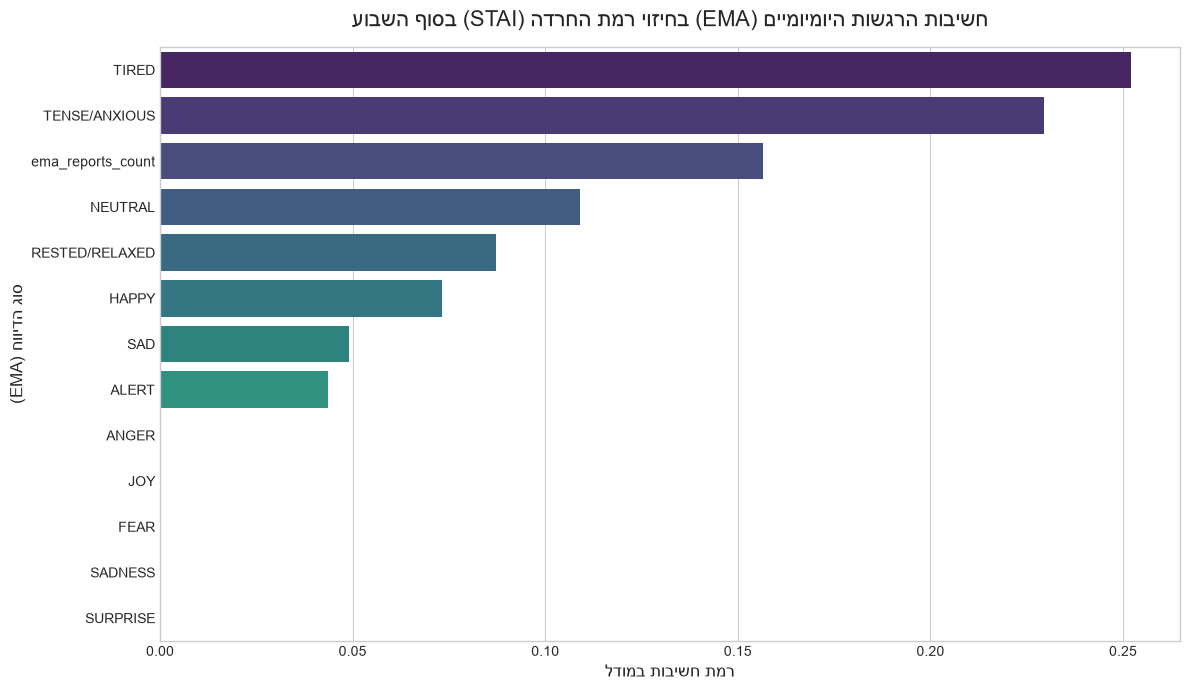

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- 2. אימון מודל למידת מכונה לחיזוי STAI ---")

# נגדיר את הפיצ'רים והמטרה
features = mood_cols + ['ema_reports_count']
target = 'stai_stress'

# העתקת הנתונים כדי לא לפגוע בטבלה המקורית
train_data = model_df.copy()

# השלמת ערכים חסרים בפיצ'רים של ה-EMA ל-0 
# (אם מישהו לא דיווח על 'עייפות' השבוע, האחוז שלו הוא 0)
train_data[features] = train_data[features].fillna(0)

# נסנן רק שורות שאולי חסר בהן ציון היעד (למרות שכבר ראינו שאין)
train_data = train_data.dropna(subset=[target])

X = train_data[features]
y = train_data[target]

# חלוקה לסט אימון (80%) וסט בדיקה (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# הגדרת ואימון מודל יער אקראי
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# ביצוע תחזיות על סט הבדיקה
predictions = rf_model.predict(X_test)

# חישוב ביצועי המודל
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"כמות תצפיות באימון: {len(X_train)}")
print(f"כמות תצפיות במבחן: {len(X_test)}")
print(f"\nביצועי המודל על סט המבחן:")
print(f"שגיאה ריבועית ממוצעת (MSE): {mse:.2f}")
print(f"אחוז השונות המוסברת (R^2): {r2:.2f}")

# ==========================================
# שרטוט גרף: חשיבות הפיצ'רים (Feature Importance)
# ==========================================
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# ננקה קצת את שמות הפיצ'רים בגרף כדי שיהיה יפה יותר
feature_importance['Feature'] = feature_importance['Feature'].str.replace('mood_', '')

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title("חשיבות הרגשות היומיומיים (EMA) בחיזוי רמת החרדה (STAI) בסוף השבוע", fontsize=16, pad=15)
plt.xlabel("רמת חשיבות במודל", fontsize=12)
plt.ylabel("סוג הדיווח (EMA)", fontsize=12)
plt.tight_layout()
plt.show()

פה ניסיתי לעשות מודל שינבא אבל כנראה שהיתה פה זליגת נתונים אז הנה מודל חדש. 


--- 2. אימון מודל - חלוקה קפדנית לפי נבדקים (Group Split) ---
כמות תצפיות באימון: 155
כמות תצפיות במבחן: 55
כמות נבדקים ייחודיים במבחן שלא נראו באימון: 10

ביצועי המודל על סט המבחן (נבדקים חדשים):
שגיאה ריבועית ממוצעת (MSE): 46.05
אחוז השונות המוסברת (R^2): -0.29


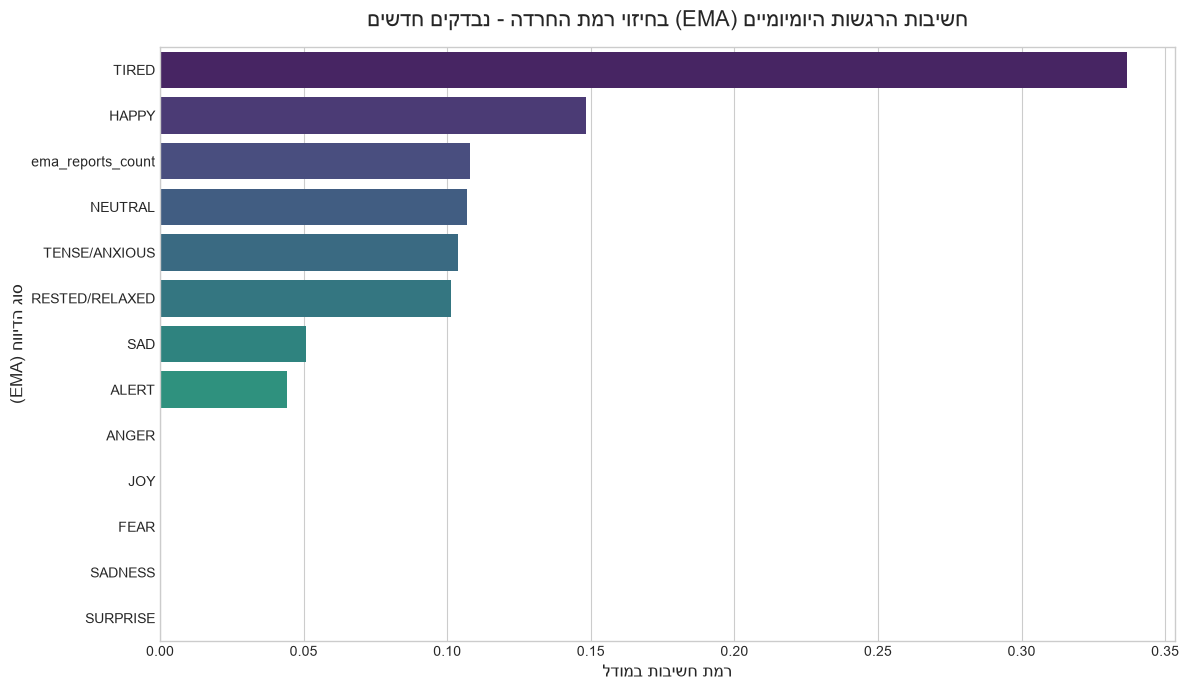

In [18]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- 2. אימון מודל - חלוקה קפדנית לפי נבדקים (Group Split) ---")

# הגדרת הפיצ'רים והמטרה
features = mood_cols + ['ema_reports_count']
target = 'stai_stress'

# העתקת הנתונים והשלמת חוסרים
train_data = model_df.copy()
train_data[features] = train_data[features].fillna(0)
train_data = train_data.dropna(subset=[target])

X = train_data[features]
y = train_data[target]

# המפתח למניעת זליגה: הגדרת קבוצות לפי מזהה הנבדק
groups = train_data['new_id'] 

# חלוקה לסט אימון (80%) וסט בדיקה (20%) כך שנבדק לא יופיע בשניהם
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# הגדרת ואימון מודל יער אקראי
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
rf_model.fit(X_train, y_train)

# ביצוע תחזיות על סט הבדיקה
predictions = rf_model.predict(X_test)

# חישוב ביצועי המודל
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"כמות תצפיות באימון: {len(X_train)}")
print(f"כמות תצפיות במבחן: {len(X_test)}")
print(f"כמות נבדקים ייחודיים במבחן שלא נראו באימון: {train_data.iloc[test_idx]['new_id'].nunique()}")

print(f"\nביצועי המודל על סט המבחן (נבדקים חדשים):")
print(f"שגיאה ריבועית ממוצעת (MSE): {mse:.2f}")
print(f"אחוז השונות המוסברת (R^2): {r2:.2f}")

# שרטוט גרף: חשיבות הפיצ'רים
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
feature_importance['Feature'] = feature_importance['Feature'].str.replace('mood_', '')

plt.figure(figsize=(12, 7))
sns.barplot(data=feature_importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("חשיבות הרגשות היומיומיים (EMA) בחיזוי רמת החרדה - נבדקים חדשים", fontsize=16, pad=15)
plt.xlabel("רמת חשיבות במודל", fontsize=12)
plt.ylabel("סוג הדיווח (EMA)", fontsize=12)
plt.tight_layout()
plt.show()

המודל לא עובד... אי אפשר להניח ממנו הנה ההסבר על פי הצאט- הפלט שקיבלת הוא קלאסי למצב של התאמת יתר (Overfitting) שהתנפצה מול המציאות:

R² של 0.29-: הציון השלילי אומר שכאשר המודל פוגש נבדקים חדשים, הוא עושה עבודה גרועה יותר מסתם לנחש את ממוצע החרדה של כולם.

ההבדל הדרמטי בין הגרפים: אם תסתכלי על הגרף מהמודל הראשון (ה"מרמה"), הרגש TENSE/ANXIOUS הוביל בפער עצום. אבל בגרף השני שהעלית (מודל הנבדקים החדשים), TIRED פתאום קפץ למקום הראשון, ו-HAPPY הגיע למקום השני.

למה זה קרה? כי במדגם קטן של 155 שבועות, המודל פשוט "שינן" התנהגויות ספציפיות. אולי היה נבדק אחד ספציפי שתמיד דיווח שהוא עייף ושמח, וגם היה לו ציון STAI גבוה מסיבות אחרות לגמרי. המודל שייך את ה"עייפות" וה"שמחה" לחרדה, וכשהוא ניסה להכליל את השטות הזו על 10 הנבדקים החדשים – הוא התרסק.

מסקנה מדעית: אי אפשר להשתמש במודל יער אקראי מורכב על הנתונים האלו כדי לנבא ציון מדויק.

הרבה פעמים בפסיכולוגיה מחקרית, הניסיון לנחש אם מישהו יקבל 45 או 47 בשאלון הוא חסר תוחלת (הרעש הסטטיסטי גדול מדי). במקום זה, נשאל שאלה בינארית קלה יותר: האם הנבדק נמצא בחרדה גבוהה (מעל חציון ה-STAI) או לא?

המודל הזה משתמש ב-Logistic Regression, שהוא סטנדרט זהב מחקרי להבנת סיכויים והסתברויות:


--- מודל ב': סיווג חרדה גבוהה מול נמוכה ---
אחוז דיוק בסיווג (Accuracy): 0.55

דו"ח ביצועים מלא:
              precision    recall  f1-score   support

 Low Anxiety       0.17      0.83      0.29         6
High Anxiety       0.96      0.51      0.67        49

    accuracy                           0.55        55
   macro avg       0.57      0.67      0.48        55
weighted avg       0.88      0.55      0.63        55



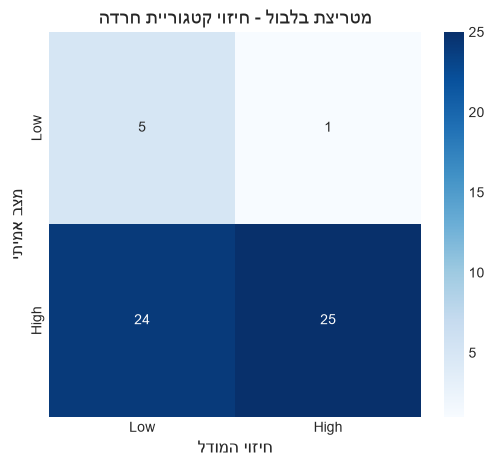

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("\n--- מודל ב': סיווג חרדה גבוהה מול נמוכה ---")

# נהפוך את ציון ה-STAI למשתנה בינארי (0 = חרדה נמוכה, 1 = חרדה גבוהה)
# נשתמש בציון 40 כסף חיתוך (אפשר לשנות לפי הספרות המחקרית)
threshold = 40 
train_data['is_high_anxiety'] = (train_data[target] >= threshold).astype(int)

y_class = train_data['is_high_anxiety']

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_class, y_test_class = y_class.iloc[train_idx], y_class.iloc[test_idx]

# אימון מודל סיווג
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train, y_train_class)

class_predictions = log_reg.predict(X_test)
accuracy = accuracy_score(y_test_class, class_predictions)

print(f"אחוז דיוק בסיווג (Accuracy): {accuracy:.2f}")
print("\nדו\"ח ביצועים מלא:")
print(classification_report(y_test_class, class_predictions, target_names=['Low Anxiety', 'High Anxiety']))

# ציור מטריצת בלבול (Confusion Matrix)
cm = confusion_matrix(y_test_class, class_predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
plt.title("מטריצת בלבול - חיזוי קטגוריית חרדה", fontsize=14)
plt.xlabel("חיזוי המודל", fontsize=12)
plt.ylabel("מצב אמיתי", fontsize=12)
plt.show()

במקום עץ החלטות שמחפש חוקים מסובכים וספציפיים, נשתמש ברגרסיה קווית עם מנגנון "ענישה" (Ridge). המודל הזה מנסה למתוח קו מגמה פשוט והגיוני, והוא קשיח מספיק כדי לא להסתנוור מנבדק אחד חריג.
היתרון הגדול: הוא ייתן לנו מקדמים (Coefficients) חיוביים ושליליים – נוכל לדעת איזה רגש מעלה את החרדה ואיזה מוריד אותה.



--- מודל א': רגרסיית Ridge לנבדקים חדשים ---
R² על סט המבחן: 0.08


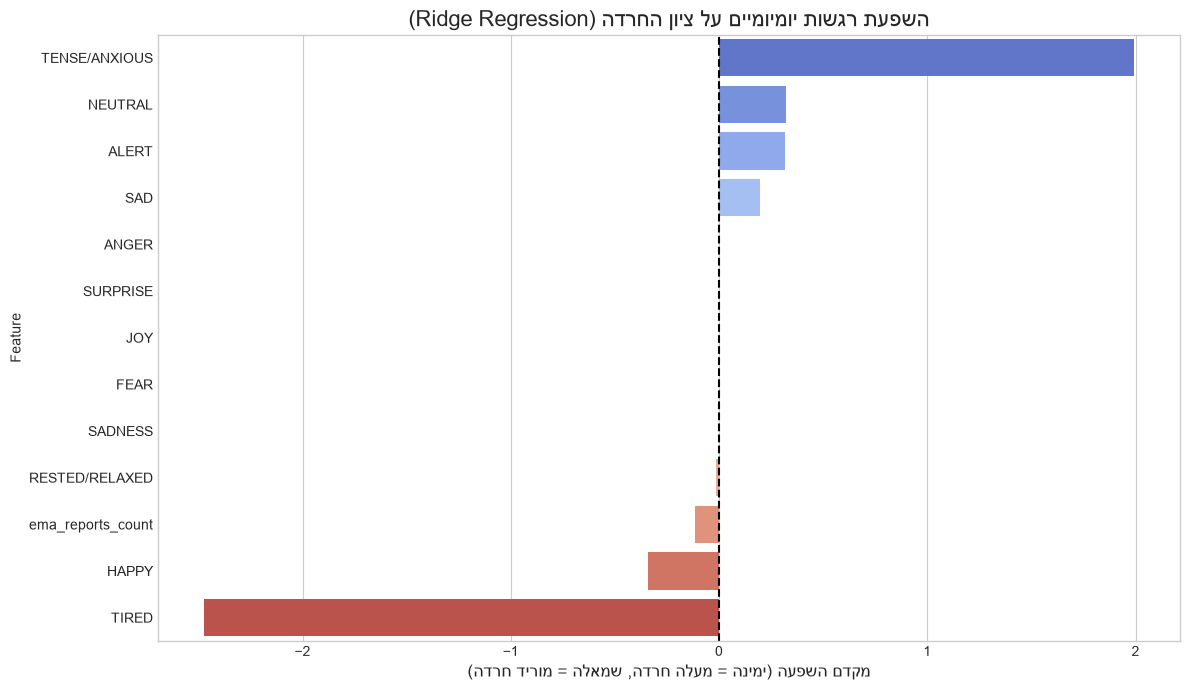

In [20]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- מודל א': רגרסיית Ridge לנבדקים חדשים ---")

features = mood_cols + ['ema_reports_count']
target = 'stai_stress'

train_data = model_df.copy()
train_data[features] = train_data[features].fillna(0)
train_data = train_data.dropna(subset=[target])

X = train_data[features]
y = train_data[target]
groups = train_data['new_id']

# חלוקה זהה לפי נבדקים
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# אימון מודל Ridge קשיח (alpha שולט ברמת ה"נוקשות")
ridge_model = Ridge(alpha=10.0, random_state=42)
ridge_model.fit(X_train, y_train)

predictions = ridge_model.predict(X_test)
r2 = r2_score(y_test, predictions)

print(f"R² על סט המבחן: {r2:.2f}")

# חילוץ המקדמים כדי להבין כיוון השפעה
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_model.coef_
}).sort_values(by='Coefficient', ascending=False)
coefficients['Feature'] = coefficients['Feature'].str.replace('mood_', '')

plt.figure(figsize=(12, 7))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title("השפעת רגשות יומיומיים על ציון החרדה (Ridge Regression)", fontsize=16)
plt.xlabel("מקדם השפעה (ימינה = מעלה חרדה, שמאלה = מוריד חרדה)", fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

--- ניתוח נקודות הידרדרות (Deterioration Points) ---
✅ מצאנו 4 מקרי הידרדרות במדגם (מעבר ממצב לא בעייתי לבעייתי).


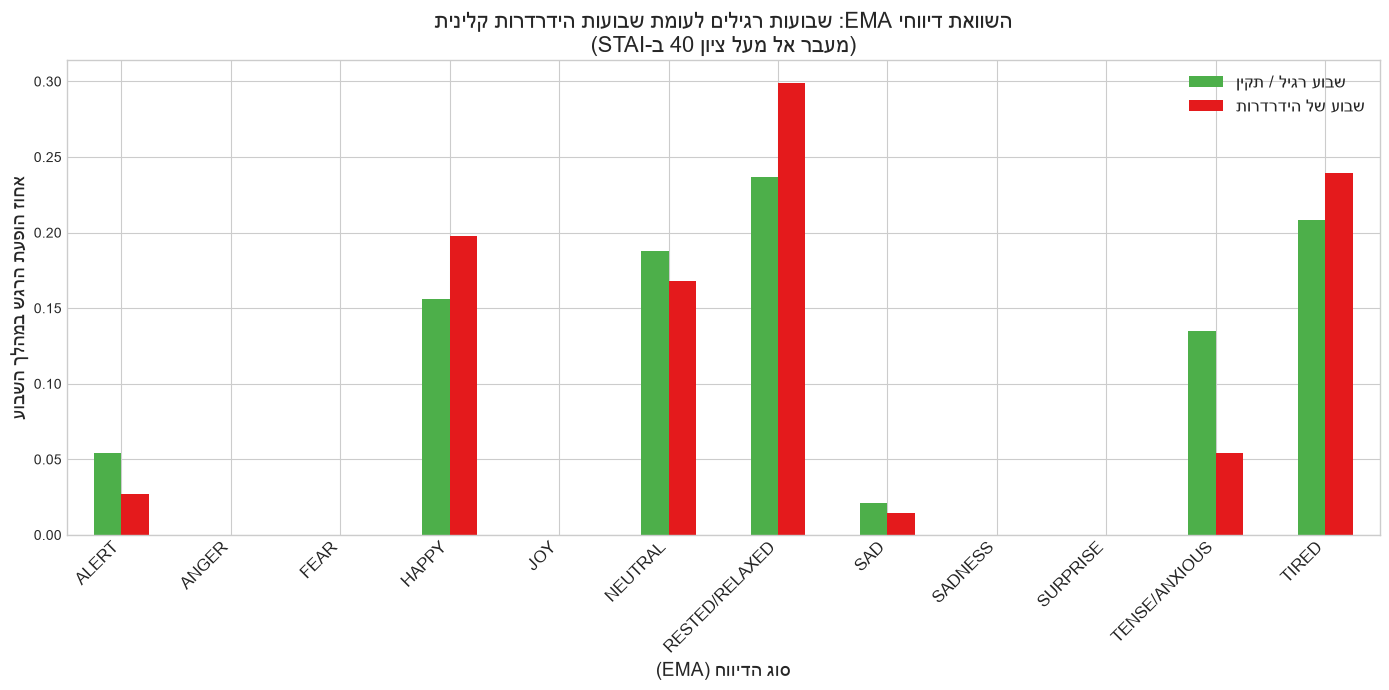

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ניתוח נקודות הידרדרות (Deterioration Points) ---")

# 1. הגדרת סף החיתוך הקליני למצב "בעייתי" (אפשר לשנות בהתאם לספרות המחקרית)
threshold = 40 

# נשתמש בטבלת model_df שכוללת כבר גם את ה-EMA וגם את ה-STAI
df_trends = model_df.sort_values(by=['new_id', 'study_week']).copy()

# 2. נחשב לכל שורה מה היה ציון החרדה של אותו נבדק בשבוע הקודם
df_trends['prev_stai'] = df_trends.groupby('new_id')['stai_stress'].shift(1)

# נסנן שורות שאין להן שבוע קודם (כמו השבוע הראשון של הניסוי)
df_trends = df_trends.dropna(subset=['prev_stai'])

# 3. נגדיר מהי הידרדרות (0 = לא הידרדר, 1 = הידרדר)
# התנאי: בשבוע שעבר היה מתחת לסף, והשבוע הוא חצה את הסף למעלה
df_trends['is_deterioration'] = ((df_trends['prev_stai'] < threshold) & 
                                 (df_trends['stai_stress'] >= threshold)).astype(int)

num_deteriorations = df_trends['is_deterioration'].sum()
print(f"✅ מצאנו {num_deteriorations} מקרי הידרדרות במדגם (מעבר ממצב לא בעייתי לבעייתי).")

if num_deteriorations > 0:
    # 4. נחשב את ממוצע ה-EMA בשבועות של הידרדרות לעומת שבועות רגילים
    # נוודא שרשימת הפיצ'רים כוללת את עמודות ה-mood שלנו
    features = [col for col in df_trends.columns if col.startswith('mood_')]
    
    # חישוב הממוצע
    comparison_df = df_trends.groupby('is_deterioration')[features].mean().T
    comparison_df.columns = ['Normal Week', 'Deterioration Week']
    
    # ניקוי שמות העמודות בגרף
    comparison_df.index = comparison_df.index.str.replace('mood_', '')
    
    # 5. ציור גרף השוואתי
    comparison_df.plot(kind='bar', figsize=(14, 7), color=['#4daf4a', '#e41a1c'])
    plt.title(f"השוואת דיווחי EMA: שבועות רגילים לעומת שבועות הידרדרות קלינית\n(מעבר אל מעל ציון {threshold} ב-STAI)", fontsize=16)
    plt.xlabel("סוג הדיווח (EMA)", fontsize=14)
    plt.ylabel("אחוז הופעת הרגש במהלך השבוע", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(['שבוע רגיל / תקין', 'שבוע של הידרדרות'], fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("לא נמצאו מקרים שעונים על ההגדרה של הידרדרות במדגם זה.")

4 מקרים הם טיפה בים וגם סף שך 40 לא אומר שמשהו אמיתי השתנה יכול להיות שהן זזו בין 39 ל41... 


--- ניתוח הידרדרות מבוסס שינוי מהותי (Delta) ---
מצאנו 8 מקרים של הידרדרות מהותית (קפיצה של לפחות 8 נקודות ב-STAI).


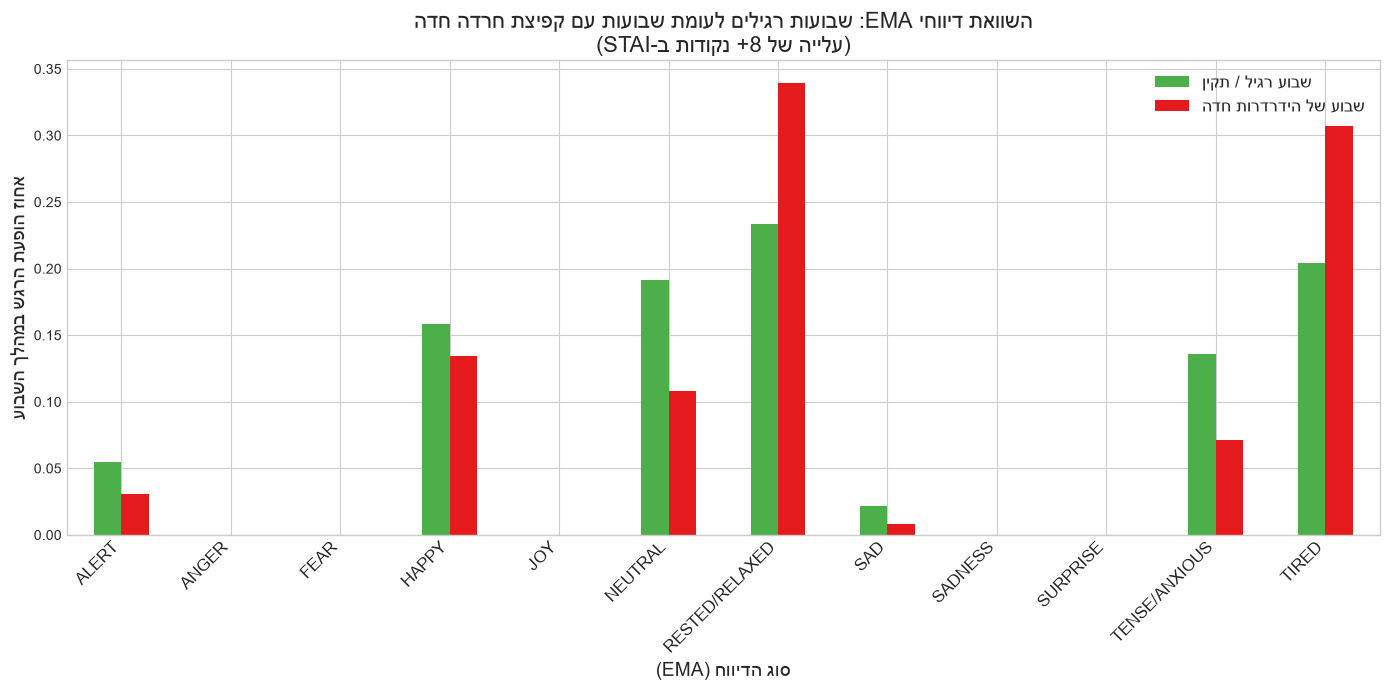

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ניתוח הידרדרות מבוסס שינוי מהותי (Delta) ---")

# נגדיר קפיצה של לפחות 8 נקודות במדד החרדה משבוע לשבוע כ"הידרדרות"
MIN_JUMP = 8 

df_trends = model_df.sort_values(by=['new_id', 'study_week']).copy()
df_trends['prev_stai'] = df_trends.groupby('new_id')['stai_stress'].shift(1)
df_trends = df_trends.dropna(subset=['prev_stai'])

# חישוב הפער (הדלתא) האמיתי בנקודות
df_trends['stai_delta'] = df_trends['stai_stress'] - df_trends['prev_stai']

# הגדרת הידרדרות: רק אם הקפיצה גדולה או שווה למינימום שהגדרנו
df_trends['is_real_deterioration'] = (df_trends['stai_delta'] >= MIN_JUMP).astype(int)

num_real = df_trends['is_real_deterioration'].sum()
print(f"מצאנו {num_real} מקרים של הידרדרות מהותית (קפיצה של לפחות {MIN_JUMP} נקודות ב-STAI).")

if num_real > 0:
    features = [col for col in df_trends.columns if col.startswith('mood_')]
    
    comparison_df = df_trends.groupby('is_real_deterioration')[features].mean().T
    comparison_df.columns = ['Normal Week', 'Severe Deterioration Week']
    comparison_df.index = comparison_df.index.str.replace('mood_', '')
    
    comparison_df.plot(kind='bar', figsize=(14, 7), color=['#4daf4a', '#e41a1c'])
    plt.title(f"השוואת דיווחי EMA: שבועות רגילים לעומת שבועות עם קפיצת חרדה חדה\n(עלייה של {MIN_JUMP}+ נקודות ב-STAI)", fontsize=16)
    plt.xlabel("סוג הדיווח (EMA)", fontsize=14)
    plt.ylabel("אחוז הופעת הרגש במהלך השבוע", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(['שבוע רגיל / תקין', 'שבוע של הידרדרות חדה'], fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("לא נמצאו מספיק מקרים שעונים על ההגדרה הנוקשה הזו.")

פה ניסיתי למצוא מקרים של הדרדרות במצב הנפשי על שאלוני חרדה של לפחות 8 נק' אבל מצאתי רק 8...


מנסה על שאלון PANAS את אותו דבר לזהות התדרדרות


--- ניתוח הידרדרות מבוסס שינוי מהותי (PANAS - Negative Affect) ---
מצאנו 26 מקרים של קפיצה חדה ברגש השלילי (עלייה של לפחות 6 נקודות ב-PANAS).


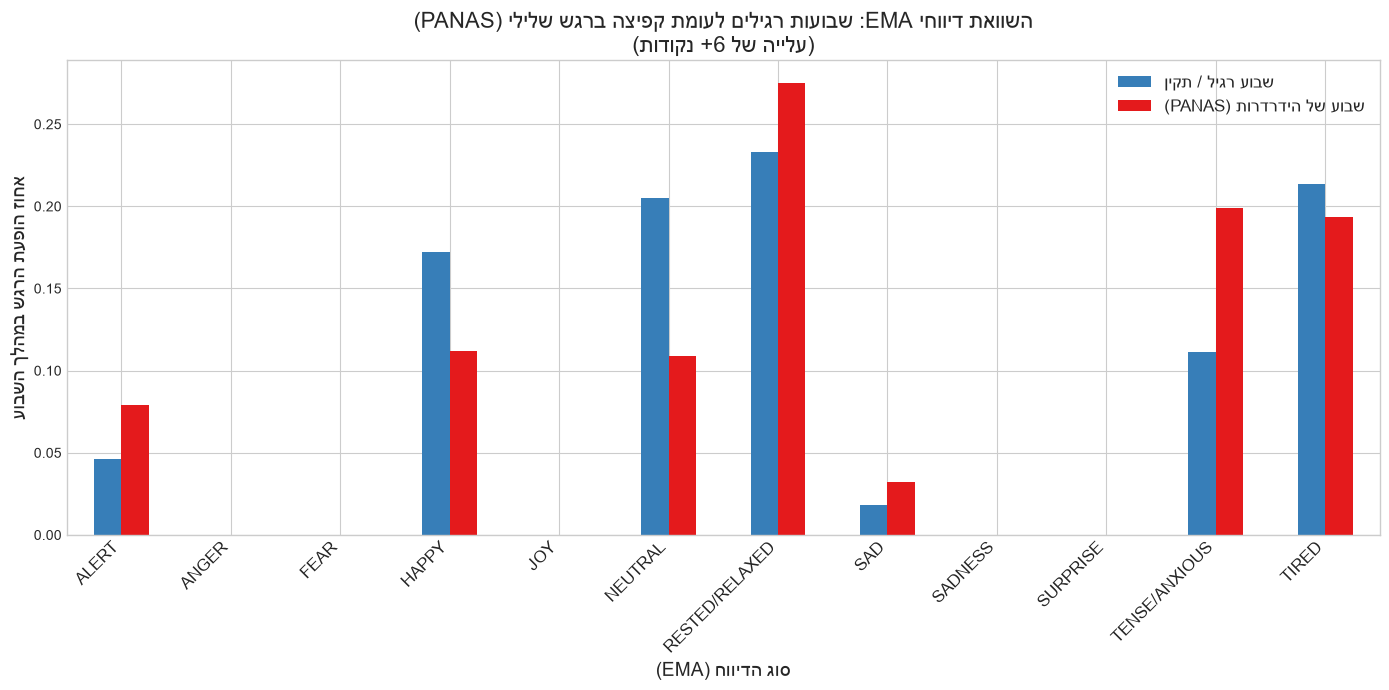

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ניתוח הידרדרות מבוסס שינוי מהותי (PANAS - Negative Affect) ---")

# נגדיר קפיצה של לפחות 6 נקודות במדד הרגש השלילי משבוע לשבוע כ"הידרדרות"
MIN_JUMP_PANAS = 6 

df_panas_trends = model_df.sort_values(by=['new_id', 'study_week']).copy()

# נחשב את הציון של הרגש השלילי מהשבוע הקודם
df_panas_trends['prev_negative_affect'] = df_panas_trends.groupby('new_id')['negative_affect_score'].shift(1)
df_panas_trends = df_panas_trends.dropna(subset=['prev_negative_affect'])

# חישוב הפער (הדלתא) האמיתי בנקודות
df_panas_trends['panas_neg_delta'] = df_panas_trends['negative_affect_score'] - df_panas_trends['prev_negative_affect']

# הגדרת הידרדרות: רק אם הקפיצה ברגש השלילי גדולה או שווה למינימום שהגדרנו
df_panas_trends['is_real_deterioration'] = (df_panas_trends['panas_neg_delta'] >= MIN_JUMP_PANAS).astype(int)

num_real_panas = df_panas_trends['is_real_deterioration'].sum()
print(f"מצאנו {num_real_panas} מקרים של קפיצה חדה ברגש השלילי (עלייה של לפחות {MIN_JUMP_PANAS} נקודות ב-PANAS).")

if num_real_panas > 0:
    features = [col for col in df_panas_trends.columns if col.startswith('mood_')]
    
    comparison_panas = df_panas_trends.groupby('is_real_deterioration')[features].mean().T
    comparison_panas.columns = ['Normal Week', 'High Negative Affect Jump']
    comparison_panas.index = comparison_panas.index.str.replace('mood_', '')
    
    comparison_panas.plot(kind='bar', figsize=(14, 7), color=['#377eb8', '#e41a1c'])
    plt.title(f"השוואת דיווחי EMA: שבועות רגילים לעומת קפיצה ברגש שלילי (PANAS)\n(עלייה של {MIN_JUMP_PANAS}+ נקודות)", fontsize=16)
    plt.xlabel("סוג הדיווח (EMA)", fontsize=14)
    plt.ylabel("אחוז הופעת הרגש במהלך השבוע", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.legend(['שבוע רגיל / תקין', 'שבוע של הידרדרות (PANAS)'], fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("לא נמצאו מספיק מקרים שעונים על ההגדרה הנוקשה הזו.")

ניסיון לעשות מודל ניבוי לPANAS רגרגסיה לוגיסטית


--- אימון מודל לחיזוי הידרדרות ברגש השלילי (PANAS) ---
כמות תצפיות באימון: 121 (מתוכן 21 הידרדרויות)
כמות תצפיות במבחן: 35 (מתוכן 5 הידרדרויות)
כמות נבדקים חדשים במבחן: 9

דו"ח ביצועים מלא על נבדקים חדשים:
                       precision    recall  f1-score   support

          Normal Week       0.84      0.70      0.76        30
Deterioration (PANAS)       0.10      0.20      0.13         5

             accuracy                           0.63        35
            macro avg       0.47      0.45      0.45        35
         weighted avg       0.73      0.63      0.67        35



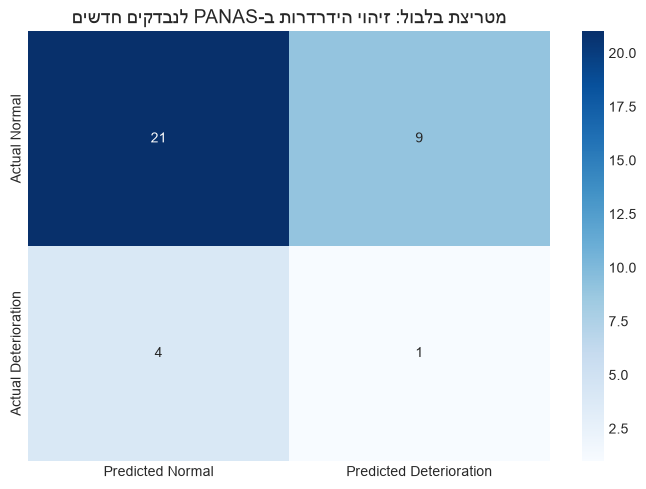

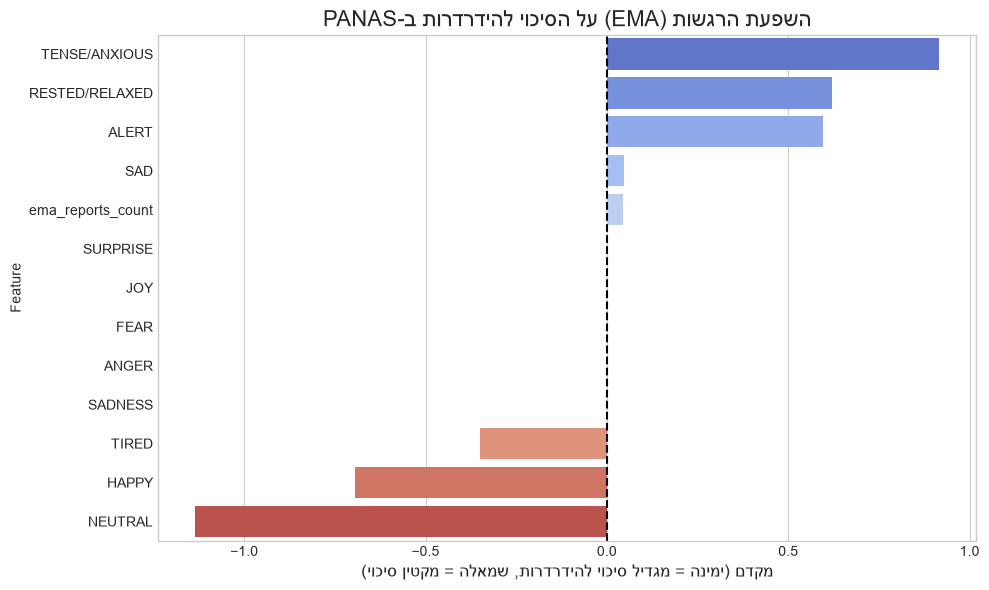

In [24]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("--- אימון מודל לחיזוי הידרדרות ברגש השלילי (PANAS) ---")

# 1. הגדרת משתנים - נשתמש בטבלה שיצרנו בשלב הקודם (df_panas_trends)
features = mood_cols + ['ema_reports_count']
target_class = 'is_real_deterioration'

train_data = df_panas_trends.copy()
train_data[features] = train_data[features].fillna(0)
train_data = train_data.dropna(subset=[target_class])

X = train_data[features]
y = train_data[target_class]
groups = train_data['new_id']

# 2. חלוקה קפדנית לפי נבדקים (למניעת זליגה)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 3. אימון המודל (Logistic Regression)
# נשתמש ב-class_weight='balanced' כדי להתמודד עם המיעוט של 26 המקרים
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

# 4. ביצוע תחזיות
predictions = model.predict(X_test)

# 5. הערכת ביצועים
print(f"כמות תצפיות באימון: {len(X_train)} (מתוכן {y_train.sum()} הידרדרויות)")
print(f"כמות תצפיות במבחן: {len(X_test)} (מתוכן {y_test.sum()} הידרדרויות)")
print(f"כמות נבדקים חדשים במבחן: {train_data.iloc[test_idx]['new_id'].nunique()}")

print("\nדו\"ח ביצועים מלא על נבדקים חדשים:")
# הדו"ח יראה לנו את מדדי ה-Precision וה-Recall
print(classification_report(y_test, predictions, target_names=['Normal Week', 'Deterioration (PANAS)']))

# 6. ציור מטריצת בלבול (Confusion Matrix)
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Deterioration'], 
            yticklabels=['Actual Normal', 'Actual Deterioration'])
plt.title("מטריצת בלבול: זיהוי הידרדרות ב-PANAS לנבדקים חדשים", fontsize=14)
plt.tight_layout()
plt.show()

# 7. מהם הפיצ'רים שהכי השפיעו על החיזוי?
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)
coefficients['Feature'] = coefficients['Feature'].str.replace('mood_', '')

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', hue='Feature', palette='coolwarm', legend=False)
plt.title("השפעת הרגשות (EMA) על הסיכוי להידרדרות ב-PANAS", fontsize=16)
plt.xlabel("מקדם (ימינה = מגדיל סיכוי להידרדרות, שמאלה = מקטין סיכוי)", fontsize=12)
plt.axvline(0, color='black', linestyle='--')
plt.tight_layout()
plt.show()